# HydroDiffusion Model Analysis
Evaluate ensemble of trained runs, visualise performance metrics and hydrographs.

In [1]:
import sys, os, json
REPO_ROOT = os.path.abspath('..')
sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

from analysis.performance_functions import nse, kge

RUNS_DIR   = Path(REPO_ROOT) / 'runs'
RAW_DIR    = Path('/projects/standard/kumarv/renga/Public/DATA/camels_us_531/RAW')
SPLIT_CSV  = Path('/projects/standard/kumarv/public/eacvi-fhnn-data/camels_split_geo.csv')

LATLONG    = np.load(RAW_DIR / 'latlong.npy',    allow_pickle=True)
BASIN_LIST = np.load(RAW_DIR / 'Basin_List.npy', allow_pickle=True)

ll_df = pd.DataFrame(LATLONG, columns=['lat', 'lon'])
ll_df['gauge_id'] = BASIN_LIST.astype(str)

split_df = pd.read_csv(SPLIT_CSV)
split_df['gauge_id'] = split_df['gauge_id'].astype(str).str.zfill(8)
print(f'Split counts: {split_df.split.value_counts().to_dict()}')
print(f'Runs dir: {RUNS_DIR}')

Split counts: {'sample': 431, 'eval': 53, 'seed': 47}
Runs dir: /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs


## Config — find completed runs

In [2]:
# Adjust MODEL_PATTERN to match the runs you want to analyse.
# Only directories that contain best_model.pt (i.e. training completed) are included.
MODEL_PATTERN = 'run_*_encdec_lstm_nosf_seed*'

run_dirs = sorted([
    p for p in RUNS_DIR.glob(MODEL_PATTERN)
    if (p / 'best_model.pt').exists()
])

print(f'Found {len(run_dirs)} completed runs:')
for r in run_dirs:
    has_preds = (r / 'predictions.npz').exists()
    print(f'  {r.name}  [{"predictions ready" if has_preds else "needs eval"  }]')

Found 5 completed runs:
  run_1805_1928_encdec_lstm_nosf_seed3409  [needs eval]
  run_1805_1928_encdec_lstm_nosf_seed3410  [needs eval]
  run_1805_1929_encdec_lstm_nosf_seed3407  [needs eval]
  run_1805_1929_encdec_lstm_nosf_seed3408  [needs eval]
  run_1805_1929_encdec_lstm_nosf_seed3411  [needs eval]


## Step 1 — Evaluate each seed (skip if predictions.npz already exists)

In [3]:
from papercode.evaluate_npy import evaluate as _evaluate

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

def _load_cfg(run_dir: Path) -> dict:
    """Load cfg.json and coerce string values back to correct Python types."""
    with open(run_dir / 'cfg.json') as f:
        raw = json.load(f)

    # cfg.json was saved with str(v) for every value — convert back
    bool_keys  = {'no_static', 'concat_static', 'cache_data', 'clip_norm', 'prenorm', 'resume', 'use_mse'}
    int_keys   = {'hidden_size', 'batch_size', 'forecast_horizon', 'seq_length',
                  'initial_forget_gate_bias', 'time_emb_dim', 'ddim_steps',
                  'stride', 'static_dim', 'lstm_nlayers', 'unet_nfeat', 'n_layers',
                  'd_model', 'd_state', 'clip_value', 'log_interval', 'num_workers'}
    float_keys = {'dropout', 'ssm_dropout', 'lr', 'lr_min', 'lr_dt', 'weight_decay',
                  'wd', 'min_dt', 'max_dt', 'cfr', 'cfi', 'learning_rate'}
    date_keys  = {'train_start', 'train_end', 'val_start', 'val_end', 'test_start', 'test_end'}

    cfg = {}
    for k, v in raw.items():
        if v == 'None':
            cfg[k] = None
        elif k in bool_keys:
            cfg[k] = v.lower() == 'true'
        elif k in int_keys:
            try: cfg[k] = int(v)
            except (ValueError, TypeError): cfg[k] = v
        elif k in float_keys:
            try: cfg[k] = float(v)
            except (ValueError, TypeError): cfg[k] = v
        elif k in date_keys:
            cfg[k] = pd.to_datetime(v)
        else:
            cfg[k] = v

    # Override / add runtime settings
    cfg['run_dir']     = str(run_dir)
    cfg['DEVICE']      = DEVICE
    cfg['num_workers'] = 2
    cfg['stride']      = cfg.get('stride') or 1
    return cfg


for run_dir in run_dirs:
    pred_path = run_dir / 'predictions.npz'
    if pred_path.exists():
        print(f'[SKIP]  {run_dir.name}')
        continue
    print(f'[EVAL]  {run_dir.name} ...')
    cfg = _load_cfg(run_dir)
    _evaluate(cfg)
    print(f'  → saved {pred_path}')

print('Done.')

Device: cuda:0
[EVAL]  run_1805_1928_encdec_lstm_nosf_seed3409 ...
=== Loading raw NPY data ===
Computed normalization scalar: {'input_means': array([   3.1308057,  352.16315  ,   15.707877 ,    6.6874995,
       1066.79     ], dtype=float32), 'input_stds': array([  7.445774, 128.22926 ,  11.238474,  10.248389, 705.96857 ],
      dtype=float32), 'output_mean': array([1.559412], dtype=float32), 'output_std': array([3.6513858], dtype=float32), 'static_means': array([ 3.3940382e+00,  2.7699397e+00, -3.2380022e-02,  1.7390670e-01,
        9.7384858e-01,  2.0802250e+01,  1.3366070e+00,  2.5183475e+02,
        5.6039300e+00,  1.2765522e-01, -1.3949274e+01,  1.0307207e+01,
        1.2950578e+00,  4.4258699e-01,  1.6578368e+00,  5.3082365e-01,
        3.6099197e+01,  3.4775379e+01,  2.0364759e+01,  7.2803632e+02,
        4.6185539e+01,  4.7723770e+02,  6.6658771e-01,  3.3387280e+00,
        2.5575531e+00,  7.4060768e-01,  3.3334652e-01], dtype=float32), 'static_stds': array([1.3664793e+00, 5.4

batches:   0%|          | 0/3400 [00:00<?, ?it/s]/projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/papercode/evaluate_npy.py:363: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  m = torch.tensor([q_means[basin_to_idx[b]] for b in b_ids], device=device, dtype=torch.float32)
batches: 100%|██████████| 3400/3400 [03:25<00:00, 16.57it/s]


[INFO] Saved deterministic predictions (N,H) to /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1928_encdec_lstm_nosf_seed3409/predictions.npz
  → saved /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1928_encdec_lstm_nosf_seed3409/predictions.npz
[EVAL]  run_1805_1928_encdec_lstm_nosf_seed3410 ...
=== Loading raw NPY data ===
Computed normalization scalar: {'input_means': array([   3.1308057,  352.16315  ,   15.707877 ,    6.6874995,
       1066.79     ], dtype=float32), 'input_stds': array([  7.445774, 128.22926 ,  11.238474,  10.248389, 705.96857 ],
      dtype=float32), 'output_mean': array([1.559412], dtype=float32), 'output_std': array([3.6513858], dtype=float32), 'static_means': array([ 3.3940382e+00,  2.7699397e+00, -3.2380022e-02,  1.7390670e-01,
        9.7384858e-01,  2.0802250e+01,  1.3366070e+00,  2.5183475e+02,
        5.6039300e+00,  1.2765522e-01, -1.3949274e+01,  1.0307207e+01,
        1.2950578e+00,  4.4258

batches: 100%|██████████| 3400/3400 [03:28<00:00, 16.31it/s]


[INFO] Saved deterministic predictions (N,H) to /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1928_encdec_lstm_nosf_seed3410/predictions.npz
  → saved /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1928_encdec_lstm_nosf_seed3410/predictions.npz
[EVAL]  run_1805_1929_encdec_lstm_nosf_seed3407 ...
=== Loading raw NPY data ===
Computed normalization scalar: {'input_means': array([   3.1308057,  352.16315  ,   15.707877 ,    6.6874995,
       1066.79     ], dtype=float32), 'input_stds': array([  7.445774, 128.22926 ,  11.238474,  10.248389, 705.96857 ],
      dtype=float32), 'output_mean': array([1.559412], dtype=float32), 'output_std': array([3.6513858], dtype=float32), 'static_means': array([ 3.3940382e+00,  2.7699397e+00, -3.2380022e-02,  1.7390670e-01,
        9.7384858e-01,  2.0802250e+01,  1.3366070e+00,  2.5183475e+02,
        5.6039300e+00,  1.2765522e-01, -1.3949274e+01,  1.0307207e+01,
        1.2950578e+00,  4.4258

...

[INFO] Saved deterministic predictions (N,H) to /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3407/predictions.npz
  → saved /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3407/predictions.npz
[EVAL]  run_1805_1929_encdec_lstm_nosf_seed3408 ...
=== Loading raw NPY data ===
Computed normalization scalar: {'input_means': array([   3.1308057,  352.16315  ,   15.707877 ,    6.6874995,
       1066.79     ], dtype=float32), 'input_stds': array([  7.445774, 128.22926 ,  11.238474,  10.248389, 705.96857 ],
      dtype=float32), 'output_mean': array([1.559412], dtype=float32), 'output_std': array([3.6513858], dtype=float32), 'static_means': array([ 3.3940382e+00,  2.7699397e+00, -3.2380022e-02,  1.7390670e-01,
        9.7384858e-01,  2.0802250e+01,  1.3366070e+00,  2.5183475e+02,
        5.6039300e+00,  1.2765522e-01, -1.3949274e+01,  1.0307207e+01,
        1.2950578e+00,  4.4258

batches: 100%|██████████| 3400/3400 [03:22<00:00, 16.80it/s]


[INFO] Saved deterministic predictions (N,H) to /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3408/predictions.npz
  → saved /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3408/predictions.npz
[EVAL]  run_1805_1929_encdec_lstm_nosf_seed3411 ...
=== Loading raw NPY data ===
Computed normalization scalar: {'input_means': array([   3.1308057,  352.16315  ,   15.707877 ,    6.6874995,
       1066.79     ], dtype=float32), 'input_stds': array([  7.445774, 128.22926 ,  11.238474,  10.248389, 705.96857 ],
      dtype=float32), 'output_mean': array([1.559412], dtype=float32), 'output_std': array([3.6513858], dtype=float32), 'static_means': array([ 3.3940382e+00,  2.7699397e+00, -3.2380022e-02,  1.7390670e-01,
        9.7384858e-01,  2.0802250e+01,  1.3366070e+00,  2.5183475e+02,
        5.6039300e+00,  1.2765522e-01, -1.3949274e+01,  1.0307207e+01,
        1.2950578e+00,  4.4258

batches: 100%|██████████| 3400/3400 [03:26<00:00, 16.50it/s]


[INFO] Saved deterministic predictions (N,H) to /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3411/predictions.npz
  → saved /projects/standard/kumarv/badit004/HydroDiffusion_ActiveLearning/runs/run_1805_1929_encdec_lstm_nosf_seed3411/predictions.npz
Done.


## Step 2 — Load predictions and aggregate across seeds

In [4]:
preds_list = []
ref = None
for run_dir in run_dirs:
    d = np.load(run_dir / 'predictions.npz', allow_pickle=True)
    if ref is None:
        ref = d
    preds_list.append(d['preds'].astype(np.float32))

ens_preds  = np.stack(preds_list, axis=0)   # (n_seeds, N, H)
mean_preds = ens_preds.mean(axis=0)         # (N, H)
seed_var   = ens_preds.var(axis=0)          # (N, H) — inter-seed variance

obs    = ref['obs'].astype(np.float32)      # (N, H)
basins = ref['basins'].astype(str)          # (N,)
dates  = pd.to_datetime(ref['dates'])       # (N,)
H      = mean_preds.shape[1]

print(f'N={len(basins):,}  H={H}  seeds={len(preds_list)}')
print(f'Unique basins: {len(np.unique(basins))}')

N=1,740,618  H=8  seeds=5
Unique basins: 531


## Step 3 — Per-basin metrics

In [5]:
unique_basins = np.unique(basins)
basin_metrics = []
for gid in unique_basins:
    mask = basins == gid
    df_bp = pd.DataFrame({'qobs': obs[mask].ravel(), 'qsim': mean_preds[mask].ravel()})
    kge_val, *_ = kge(df_bp)
    basin_metrics.append({'gauge_id': gid, 'nse': nse(df_bp), 'kge': kge_val})

metrics_df = (pd.DataFrame(basin_metrics)
              .merge(split_df[['gauge_id','split']], on='gauge_id', how='left')
              .merge(ll_df, on='gauge_id', how='left'))

print('Overall:')
print(metrics_df[['nse','kge']].describe().round(3))
print('\nMedian by split:')
print(metrics_df.groupby('split')[['nse','kge']].median().round(3))

Overall:
           nse      kge
count  531.000  531.000
mean     0.670    0.679
std      0.295    0.207
min     -3.072   -0.628
25%      0.627    0.615
50%      0.744    0.738
75%      0.804    0.817
max      0.931    0.928

Median by split:
          nse    kge
split               
eval    0.724  0.732
sample  0.745  0.737
seed    0.750  0.761


## Step 4 — Loss curves

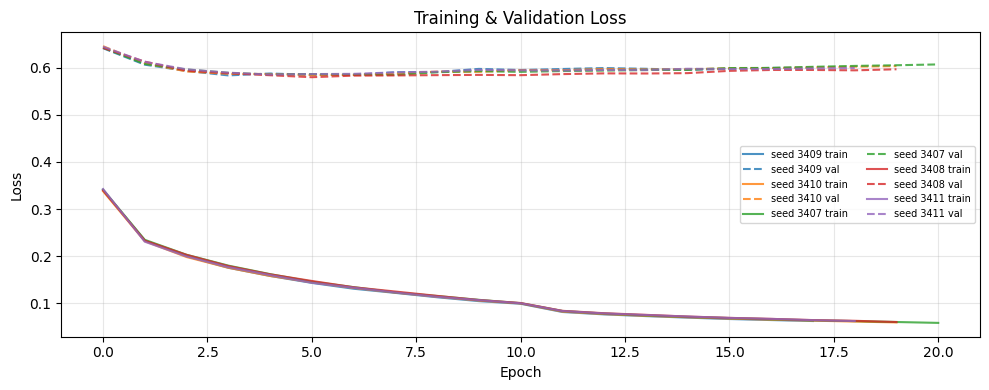

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10.colors
for i, run_dir in enumerate(run_dirs):
    loss_path = run_dir / 'loss_history.json'
    if not loss_path.exists(): continue
    with open(loss_path) as f:
        hist = json.load(f)
    seed = run_dir.name.split('seed')[-1]
    ax.plot(hist['train_loss'], color=colors[i], ls='-',  label=f'seed {seed} train', alpha=0.8)
    ax.plot(hist['val_loss'],   color=colors[i], ls='--', label=f'seed {seed} val',   alpha=0.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training & Validation Loss')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 5 — NSE / KGE boxplots by split

/tmp/ipykernel_3692564/395521933.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_3692564/395521933.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


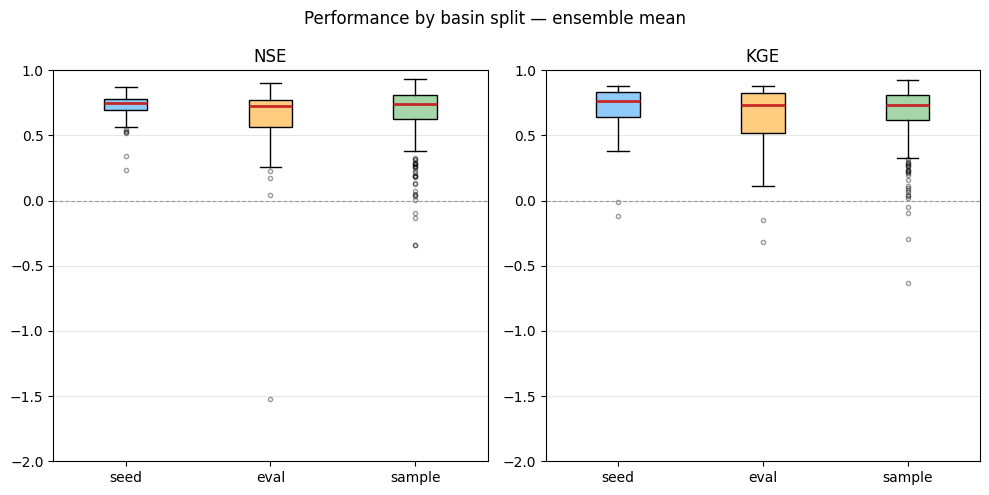

In [7]:
palette = {'seed': '#90CAF9', 'eval': '#FFCC80', 'sample': '#A5D6A7'}
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, metric in zip(axes, ['nse', 'kge']):
    data, labels, colors = [], [], []
    for sp in ['seed', 'eval', 'sample']:
        vals = metrics_df.loc[metrics_df['split'] == sp, metric].dropna().values
        if len(vals): data.append(vals); labels.append(sp); colors.append(palette[sp])
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='#C62828', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c)
    ax.set_title(metric.upper()); ax.set_ylim(-2, 1)
    ax.axhline(0, color='#999', ls='--', lw=0.8); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Performance by basin split — ensemble mean')
plt.tight_layout(); plt.show()

## Step 6 — NSE by forecast lead day

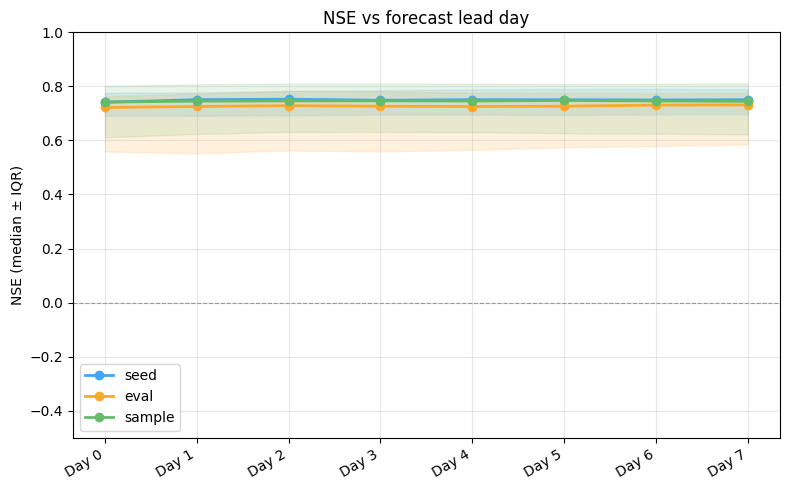

In [8]:
lead_nse = {sp: [] for sp in ['seed', 'eval', 'sample']}
for gid in unique_basins:
    mask = basins == gid
    sp_arr = metrics_df.loc[metrics_df['gauge_id'] == gid, 'split'].values
    if len(sp_arr) == 0 or sp_arr[0] not in lead_nse: continue
    sp = sp_arr[0]
    lead_nse[sp].append([nse(pd.DataFrame({'qobs': obs[mask, t], 'qsim': mean_preds[mask, t]})) for t in range(H)])

fig, ax = plt.subplots(figsize=(8, 5))
pal = {'seed': '#42A5F5', 'eval': '#FFA726', 'sample': '#66BB6A'}
days = np.arange(H)
for sp, color in pal.items():
    arr = np.array(lead_nse[sp])
    if arr.size == 0: continue
    med = np.nanmedian(arr, axis=0)
    ax.plot(days, med, color=color, marker='o', lw=2, label=sp)
    ax.fill_between(days, np.nanpercentile(arr, 25, axis=0), np.nanpercentile(arr, 75, axis=0), color=color, alpha=0.15)
ax.set_xticks(days); ax.set_xticklabels([f'Day {d}' for d in days], rotation=30, ha='right')
ax.set_ylabel('NSE (median ± IQR)'); ax.set_ylim(-0.5, 1.0)
ax.axhline(0, color='#999', ls='--', lw=0.8); ax.set_title('NSE vs forecast lead day')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 7 — Spatial map of NSE

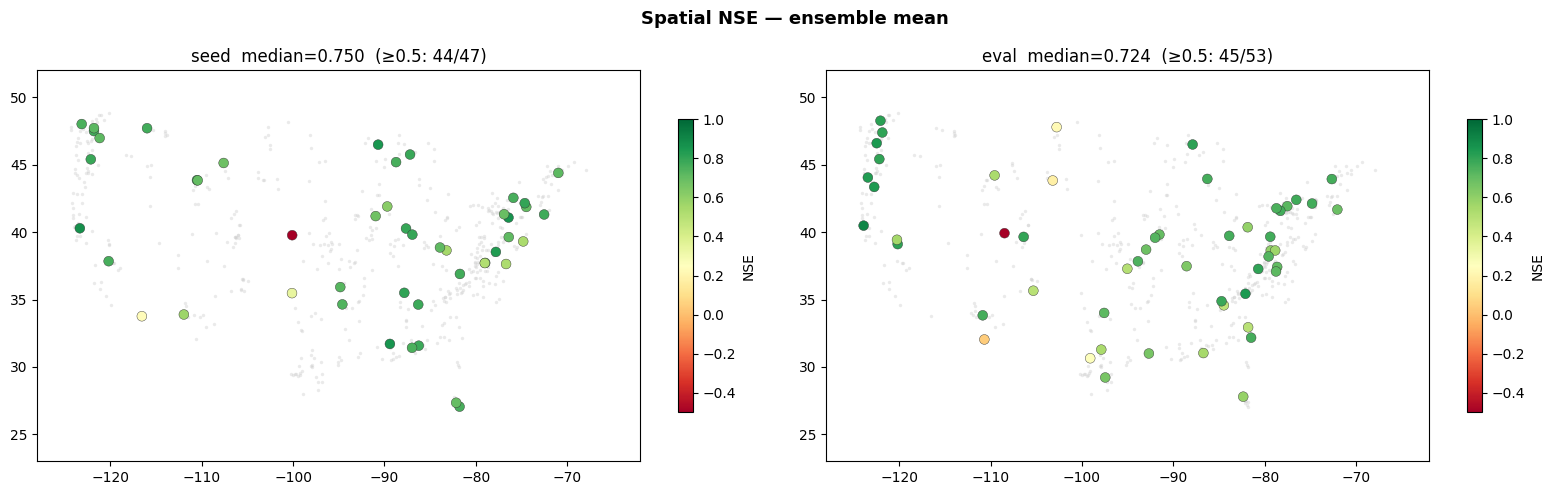

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, sp in zip(axes, ['seed', 'eval']):
    sub = metrics_df[metrics_df['split'] == sp].dropna(subset=['lat', 'lon', 'nse'])
    ax.scatter(ll_df['lon'], ll_df['lat'], s=6, c='#CCCCCC', alpha=0.4, linewidths=0)
    sc = ax.scatter(sub['lon'], sub['lat'], c=sub['nse'],
                    cmap='RdYlGn', vmin=-0.5, vmax=1.0, s=50, edgecolors='#333', linewidths=0.3)
    plt.colorbar(sc, ax=ax, shrink=0.75, label='NSE')
    ax.set_title(f'{sp}  median={sub["nse"].median():.3f}  (≥0.5: {(sub["nse"]>=0.5).sum()}/{len(sub)})')
    ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
fig.suptitle('Spatial NSE — ensemble mean', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 8 — Hydrographs: best and worst basins per split


── seed ──


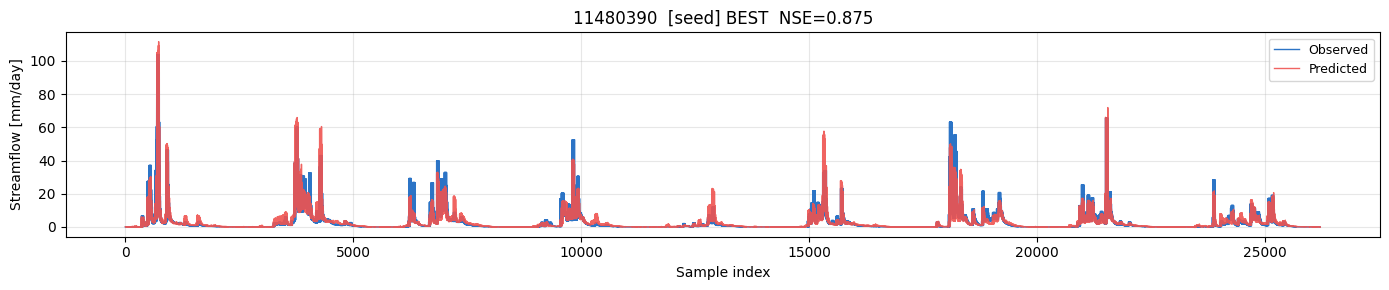

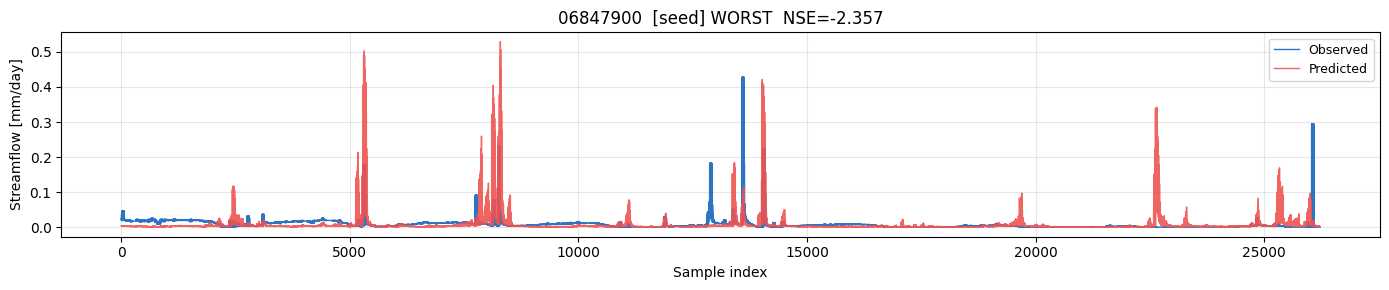


── eval ──


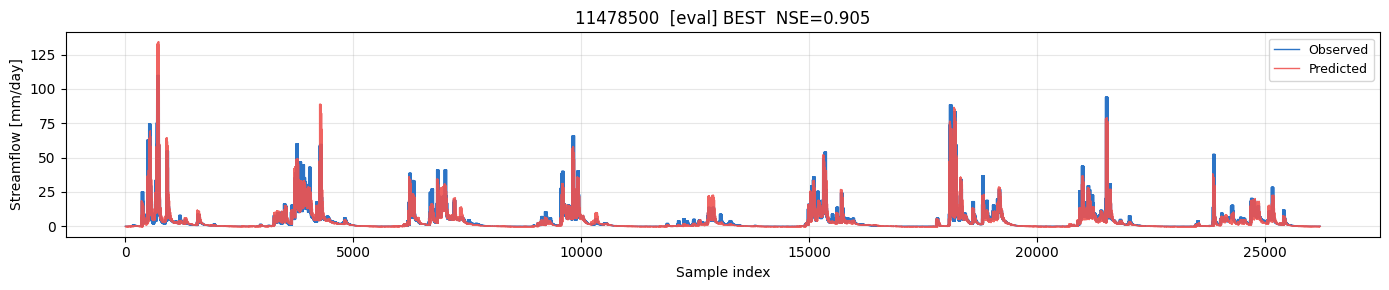

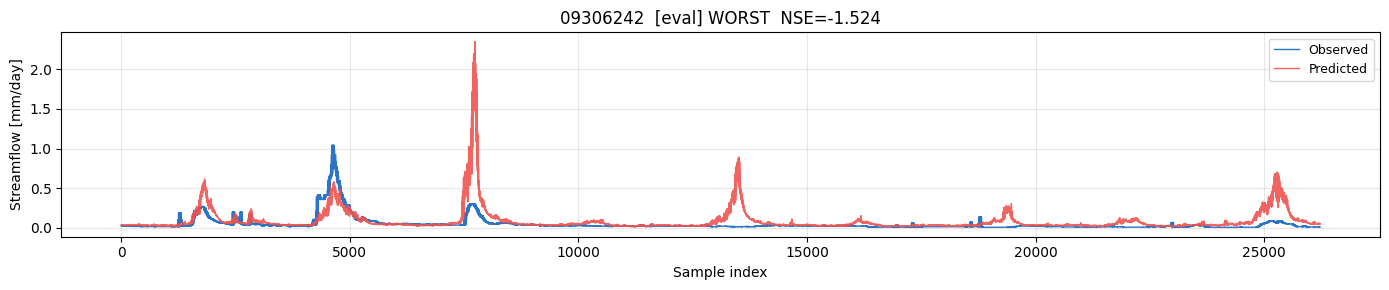

In [10]:
def plot_hydrograph(gauge_id, label=''):
    mask = basins == gauge_id
    if not mask.any(): return
    o = obs[mask].ravel()
    p = mean_preds[mask].ravel()
    nse_val = nse(pd.DataFrame({'qobs': o, 'qsim': p}))
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(o, color='#1565C0', lw=1, alpha=0.9, label='Observed')
    ax.plot(p, color='#EF5350', lw=1, alpha=0.9, label='Predicted')
    ax.set_title(f'{gauge_id}  {label}  NSE={nse_val:.3f}')
    ax.set_xlabel('Sample index'); ax.set_ylabel('Streamflow [mm/day]')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

for sp in ['seed', 'eval']:
    sub = metrics_df[metrics_df['split'] == sp].dropna(subset=['nse'])
    if sub.empty: continue
    print(f'\n── {sp} ──')
    plot_hydrograph(sub.nlargest(1, 'nse')['gauge_id'].iloc[0],  f'[{sp}] BEST')
    plot_hydrograph(sub.nsmallest(1, 'nse')['gauge_id'].iloc[0], f'[{sp}] WORST')

## Step 9 — Seed ensemble variance (UQ signal for active learning)

Top-10 most uncertain pool basins:
gauge_id  seed_var      lat        lon
14400000  2.881716 42.12344 -124.18731
14138800  1.483665 45.45262 -121.89147
12040500  1.483026 47.53786 -124.31575
14138900  1.438155 45.49429 -122.03592
12056500  1.430446 47.51426 -123.32989
12041200  1.425621 47.80675 -124.25103
11532500  1.247286 41.79150 -124.07619
11476600  1.006282 40.35125 -124.00393
02427250  0.987970 31.99626  -87.06832
14138870  0.970300 45.48012 -122.02564


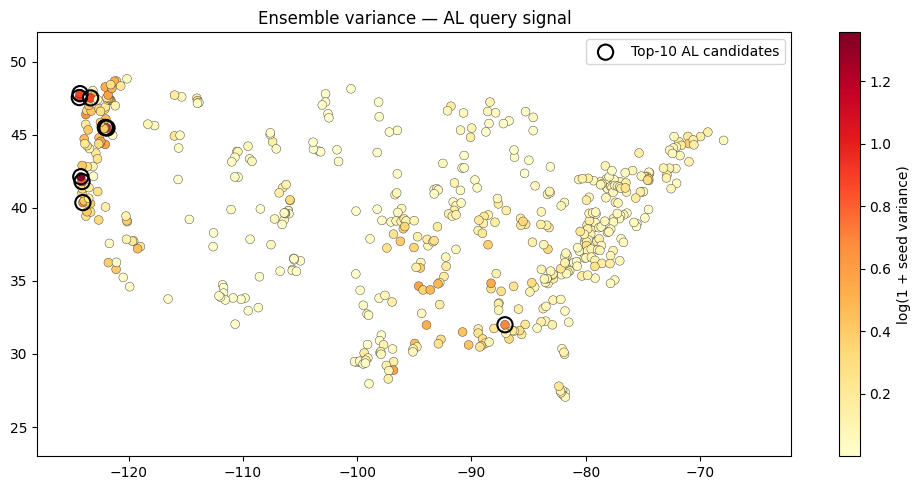

In [11]:
var_df = pd.DataFrame({
    'gauge_id': [gid for gid in unique_basins],
    'seed_var': [float(seed_var[basins == gid].mean()) for gid in unique_basins],
})
var_df = (var_df.merge(split_df[['gauge_id','split']], on='gauge_id', how='left')
                .merge(ll_df, on='gauge_id', how='left'))

pool_candidates = var_df[var_df['split'] == 'sample'].nlargest(10, 'seed_var')
print('Top-10 most uncertain pool basins:')
print(pool_candidates[['gauge_id','seed_var','lat','lon']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(ll_df['lon'], ll_df['lat'], s=6, c='#CCCCCC', alpha=0.4, linewidths=0)
sc = ax.scatter(var_df['lon'], var_df['lat'], c=np.log1p(var_df['seed_var']),
                cmap='YlOrRd', s=40, edgecolors='#333', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='log(1 + seed variance)')
ax.scatter(pool_candidates['lon'], pool_candidates['lat'],
           s=120, facecolors='none', edgecolors='black', lw=1.5, zorder=5, label='Top-10 AL candidates')
ax.set_title('Ensemble variance — AL query signal')
ax.set_xlim(-128, -62); ax.set_ylim(23, 52)
ax.legend(); plt.tight_layout(); plt.show()